# Лабораторная работа №4
## Классификация временных рядов ЭЭГ для определения эпилептического приступа

В работе используется фрагмент базы CHB-MIT Scalp EEG Database для пациента `chb08`.

Цель эксперимента — сформировать обучающую выборку из EEG-фрагментов с приступом и без приступа, построить для каждого фрагмента вейвлет-изображение и обучить свёрточную нейронную сеть для бинарной классификации.

In [ ]:
from pathlib import Path

DOWNLOAD_DIR = Path("/kaggle/working/chb08")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

print("Download directory:", DOWNLOAD_DIR)

Download directory: /kaggle/working/chb08


In [9]:
%%bash
mkdir -p /kaggle/working/chb08

BASE_URL="https://physionet.org/files/chbmit/1.0.0/chb08"
OUT_DIR="/kaggle/working/chb08"

FILES=(
  "chb08-summary.txt"

  "chb08_02.edf"
  "chb08_02.edf.seizures"

  "chb08_05.edf"
  "chb08_05.edf.seizures"

  "chb08_11.edf"
  "chb08_11.edf.seizures"

  "chb08_13.edf"
  "chb08_13.edf.seizures"

  "chb08_21.edf"
  "chb08_21.edf.seizures"

  "chb08_03.edf"
  "chb08_04.edf"
  "chb08_10.edf"
  "chb08_12.edf"
  "chb08_14.edf"
  "chb08_15.edf"
  "chb08_16.edf"
  "chb08_17.edf"
  "chb08_18.edf"
  "chb08_19.edf"
  "chb08_20.edf"
  "chb08_22.edf"
  "chb08_23.edf"
  "chb08_24.edf"
  "chb08_29.edf"
)

for file in "${FILES[@]}"; do
  echo "Downloading $file ..."
  wget -c -q --show-progress "$BASE_URL/$file" -P "$OUT_DIR"
done

echo "Done."

Done.



        [ skipping 19700K ]
 19700K ,,,,,,,,,, .......... .......... .......... .......... 47% 56.2K 8m7s
 19750K .......... .......... .......... .......... .......... 47% 54.0K 7m18s
 19800K .......... .......... .......... .......... .......... 47% 37.0K 8m9s
 19850K .......... .......... .......... .......... .......... 48% 76.2K 7m14s
 19900K .......... .......... .......... .......... .......... 48% 67.4K 6m49s
 19950K .......... .......... .......... .......... .......... 48% 55.1K 6m45s
 20000K .......... .......... .......... .......... .......... 48% 73.5K 6m27s
 20050K .......... .......... .......... .......... .......... 48% 64.9K 6m19s
 20100K .......... .......... .......... .......... .......... 48% 60.2K 6m15s
 20150K .......... .......... .......... .......... .......... 48% 67.6K 6m8s
 20200K .......... .......... .......... .......... .......... 48% 64.7K 6m3s
 20250K .......... .......... .......... .......... .......... 49% 68.1K 5m58s
 20300K .......... ........

In [12]:
from pathlib import Path

files = sorted(Path("/kaggle/working/chb08").glob("*"))

print("عدد الملفات:", len(files))
for f in files:
    print(f.name)

عدد الملفات: 26
chb08-summary.txt
chb08_02.edf
chb08_02.edf.seizures
chb08_03.edf
chb08_04.edf
chb08_05.edf
chb08_05.edf.seizures
chb08_10.edf
chb08_11.edf
chb08_11.edf.seizures
chb08_12.edf
chb08_13.edf
chb08_13.edf.seizures
chb08_14.edf
chb08_15.edf
chb08_16.edf
chb08_17.edf
chb08_18.edf
chb08_19.edf
chb08_20.edf
chb08_21.edf
chb08_21.edf.seizures
chb08_22.edf
chb08_23.edf
chb08_24.edf
chb08_29.edf


In [13]:
# =========================
# Cell 2 — Imports
# =========================
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import pywt
import mne
from scipy.signal import butter, filtfilt, resample

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)

2026-04-29 12:10:28.308127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777464628.552467      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777464628.622281      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777464629.174778      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777464629.174810      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777464629.174813      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [14]:
# =========================
# Cell 5 — Paths
# =========================

DATA_DIR = Path("/kaggle/working/chb08")

WORK_DIR = Path("/kaggle/working/lab4_colored_scalograms")
DATASET_DIR = WORK_DIR / "eeg_image_dataset"
SEIZURE_DIR = DATASET_DIR / "seizure"
NON_SEIZURE_DIR = DATASET_DIR / "non_seizure"

RESULTS_DIR = WORK_DIR / "results"
MODEL_DIR = WORK_DIR / "model"

for d in [WORK_DIR, DATASET_DIR, SEIZURE_DIR, NON_SEIZURE_DIR, RESULTS_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("MODEL_DIR:", MODEL_DIR)

DATA_DIR: /kaggle/working/chb08
DATASET_DIR: /kaggle/working/lab4_colored_scalograms/eeg_image_dataset
RESULTS_DIR: /kaggle/working/lab4_colored_scalograms/results
MODEL_DIR: /kaggle/working/lab4_colored_scalograms/model


In [16]:
# =========================
# Cell 6 — Experiment configuration and files
# =========================

SAMPLING_RATE = 256

# ملفات تحتوي على نوبات
seizure_records = [
    {"file": "chb08_02.edf", "start": 2670, "end": 2841},
    {"file": "chb08_05.edf", "start": 2856, "end": 3046},
    {"file": "chb08_11.edf", "start": 2988, "end": 3122},
    {"file": "chb08_13.edf", "start": 2417, "end": 2577},
    {"file": "chb08_21.edf", "start": 2083, "end": 2347},
]

# ملفات بدون نوبات
non_seizure_files = [
    "chb08_03.edf",
    "chb08_04.edf",
    "chb08_10.edf",
    "chb08_12.edf",
    "chb08_14.edf",
    "chb08_15.edf",
    "chb08_16.edf",
    "chb08_17.edf",
    "chb08_18.edf",
    "chb08_19.edf",
    "chb08_20.edf",
    "chb08_22.edf",
    "chb08_23.edf",
    "chb08_24.edf",
    "chb08_29.edf",
]

# إعدادات تكوين الصور
N_IMAGES_PER_CLASS = 50
SEGMENT_DURATION_SEC = 8.0

# إعدادات المخطط الطيفي/السكيلوغرام
TARGET_FS = 128
LOWPASS_CUTOFF = 60
FREQ_MIN = 1
FREQ_MAX = 60
N_SCALES = 128
IMG_SIZE = (128, 128)
CMAP_NAME = "turbo"   # يمكن تغييره إلى viridis أو plasma

# إعدادات التدريب
BATCH_SIZE = 8
EPOCHS = 40

all_required_files = [r["file"] for r in seizure_records] + non_seizure_files
missing_files = [f for f in all_required_files if not (DATA_DIR / f).exists()]

if missing_files:
    print("الملفات الناقصة:")
    for f in missing_files:
        print(f)
    raise FileNotFoundError("بعض ملفات EDF غير موجودة. تأكد من تنفيذ خلية التحميل.")
else:
    print("كل ملفات EDF المطلوبة موجودة.")

print("Seizure EDF files:", len(seizure_records))
print("Non-seizure EDF files:", len(non_seizure_files))
print("Images per class:", N_IMAGES_PER_CLASS)
print("Segment duration:", SEGMENT_DURATION_SEC, "s")

كل ملفات EDF المطلوبة موجودة.
Seizure EDF files: 5
Non-seizure EDF files: 15
Images per class: 50
Segment duration: 8.0 s


На данном этапе выполняется автоматический поиск файлов внутри директории `/kaggle/input`.  
В работе используются два EDF-файла: `chb08_21.edf` для класса с приступом и `chb08_03.edf` для класса без приступа.

In [17]:
# =========================
# Cell 7 — Read EDF metadata
# =========================

all_edf_files = [r["file"] for r in seizure_records] + non_seizure_files

sfreqs = {}
durations = {}
channel_sets = []

for filename in all_edf_files:
    raw_tmp = mne.io.read_raw_edf(DATA_DIR / filename, preload=False, verbose="ERROR")
    
    sfreqs[filename] = raw_tmp.info["sfreq"]
    durations[filename] = raw_tmp.n_times / raw_tmp.info["sfreq"]
    channel_sets.append(set(raw_tmp.ch_names))
    
    print(filename)
    print("  sampling rate:", sfreqs[filename])
    print("  duration:", round(durations[filename], 2), "s")
    print("  channels:", len(raw_tmp.ch_names))

print("تمت قراءة معلومات الملفات بنجاح.")

chb08_02.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_05.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_11.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_13.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_21.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_03.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_04.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_10.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_12.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_14.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_15.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_16.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_17.edf
  sampling rate: 256.0
  duration: 3600.0 s
  channels: 23
chb08_18.edf
  sampling rate: 256.0
  duration: 3600.0 s
  chann

In [18]:
# =========================
# Cell 8 — Common EEG channels
# =========================

common_channels = sorted(list(set.intersection(*channel_sets)))

print("عدد القنوات المشتركة بين جميع الملفات:", len(common_channels))
print(common_channels)

عدد القنوات المشتركة بين جميع الملفات: 23
['C3-P3', 'C4-P4', 'CZ-PZ', 'F3-C3', 'F4-C4', 'F7-T7', 'F8-T8', 'FP1-F3', 'FP1-F7', 'FP2-F4', 'FP2-F8', 'FT10-T8', 'FT9-FT10', 'FZ-CZ', 'P3-O1', 'P4-O2', 'P7-O1', 'P7-T7', 'P8-O2', 'T7-FT9', 'T7-P7', 'T8-P8-0', 'T8-P8-1']


In [19]:
# =========================
# Cell 9 — Signal preprocessing and colored scalogram functions
# =========================

def butter_lowpass_filter(signal_1d, cutoff, fs, order=4):
    """
    Low-pass Butterworth filter.
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    
    if normal_cutoff >= 1:
        return signal_1d.copy()
    
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return filtfilt(b, a, signal_1d)


def preprocess_channel_signal(signal_1d, orig_fs, target_fs=TARGET_FS, lowpass_cutoff=LOWPASS_CUTOFF):
    """
    معالجة قناة واحدة:
    1) إزالة الترددات فوق 60 Hz
    2) إعادة أخذ العينات إلى TARGET_FS
    3) z-score normalization
    """
    filtered = butter_lowpass_filter(signal_1d, cutoff=lowpass_cutoff, fs=orig_fs, order=4)
    
    if int(orig_fs) != int(target_fs):
        n_target = int(len(filtered) * target_fs / orig_fs)
        filtered = resample(filtered, n_target)
    
    filtered = filtered.astype(np.float32)
    filtered = (filtered - np.mean(filtered)) / (np.std(filtered) + 1e-8)
    
    return filtered


def create_colored_scalogram_from_segment(multichannel_segment, orig_fs):
    """
    ينشئ صورة scalogram ملوّنة من مقطع EEG متعدد القنوات.

    الفكرة:
    - نحسب CWT لكل قناة.
    - نحسب power = |coeffs|^2.
    - نأخذ متوسط power عبر القنوات.
    - نطبق robust normalization.
    - نحول الخريطة إلى RGB باستخدام colormap.
    """
    channel_powers = []
    
    scales = np.arange(1, N_SCALES + 1)
    
    for ch in multichannel_segment:
        ch_processed = preprocess_channel_signal(
            ch,
            orig_fs=orig_fs,
            target_fs=TARGET_FS,
            lowpass_cutoff=LOWPASS_CUTOFF
        )
        
        coeffs, freqs = pywt.cwt(
            ch_processed,
            scales,
            "morl",
            sampling_period=1 / TARGET_FS
        )
        
        power = np.abs(coeffs) ** 2
        
        valid_freqs = (freqs >= FREQ_MIN) & (freqs <= FREQ_MAX)
        power = power[valid_freqs, :]
        
        channel_powers.append(power)
    
    # متوسط الطاقة عبر القنوات
    mean_power = np.mean(np.stack(channel_powers, axis=0), axis=0)
    
    # Log compression
    mean_power = np.log1p(mean_power)
    
    # Robust normalization
    p_low, p_high = np.percentile(mean_power, [5, 99])
    norm_power = np.clip((mean_power - p_low) / (p_high - p_low + 1e-8), 0, 1)
    
    # تحويل إلى RGB
    cmap = plt.get_cmap(CMAP_NAME)
    rgb = (cmap(norm_power)[..., :3] * 255).astype(np.uint8)
    
    img = Image.fromarray(rgb)
    img = img.resize(IMG_SIZE)
    
    return img


def extract_segment(raw, start_sec, duration_sec):
    """
    يقتطع مقطع EEG متعدد القنوات من raw.
    """
    fs = raw.info["sfreq"]
    start_sample = int(start_sec * fs)
    stop_sample = int((start_sec + duration_sec) * fs)
    
    data = raw.get_data(start=start_sample, stop=stop_sample) * 1e6  # V -> µV
    
    return data

In [20]:
common_channels = sorted(list(set.intersection(*channel_sets)))

print("عدد القنوات المشتركة بين جميع الملفات:", len(common_channels))
print(common_channels)

عدد القنوات المشتركة بين جميع الملفات: 23
['C3-P3', 'C4-P4', 'CZ-PZ', 'F3-C3', 'F4-C4', 'F7-T7', 'F8-T8', 'FP1-F3', 'FP1-F7', 'FP2-F4', 'FP2-F8', 'FT10-T8', 'FT9-FT10', 'FZ-CZ', 'P3-O1', 'P4-O2', 'P7-O1', 'P7-T7', 'P8-O2', 'T7-FT9', 'T7-P7', 'T8-P8-0', 'T8-P8-1']


In [21]:
# =========================
# Cell 10 — Segment plan
# =========================

def distribute_counts(total, n_sources):
    base = total // n_sources
    remainder = total % n_sources
    return [base + 1 if i < remainder else base for i in range(n_sources)]


segment_plan = []

# توزيع 50 مقطع seizure على 5 ملفات
seizure_counts = distribute_counts(N_IMAGES_PER_CLASS, len(seizure_records))

for record, count in zip(seizure_records, seizure_counts):
    file = record["file"]
    start = record["start"]
    end = record["end"]
    
    max_start = end - SEGMENT_DURATION_SEC
    
    starts = np.linspace(start, max_start, count)
    
    for s in starts:
        segment_plan.append({
            "file": file,
            "start_sec": float(s),
            "duration_sec": SEGMENT_DURATION_SEC,
            "label": 1,
            "class_name": "seizure"
        })

# توزيع 50 مقطع non_seizure على 5 ملفات
non_counts = distribute_counts(N_IMAGES_PER_CLASS, len(non_seizure_files))

for file, count in zip(non_seizure_files, non_counts):
    duration = durations[file]
    
    min_start = 30
    max_start = duration - SEGMENT_DURATION_SEC - 30
    
    starts = np.linspace(min_start, max_start, count)
    
    for s in starts:
        segment_plan.append({
            "file": file,
            "start_sec": float(s),
            "duration_sec": SEGMENT_DURATION_SEC,
            "label": 0,
            "class_name": "non_seizure"
        })

segment_plan_df = pd.DataFrame(segment_plan)

display(segment_plan_df.head())
print("عدد مقاطع seizure:", (segment_plan_df["label"] == 1).sum())
print("عدد مقاطع non_seizure:", (segment_plan_df["label"] == 0).sum())
print("المجموع:", len(segment_plan_df))

,file,start_sec,duration_sec,label,class_name
0,chb08_02.edf,2670.000000,8.0,1,seizure
1,chb08_02.edf,2688.111111,8.0,1,seizure
2,chb08_02.edf,2706.222222,8.0,1,seizure
3,chb08_02.edf,2724.333333,8.0,1,seizure
4,chb08_02.edf,2742.444444,8.0,1,seizure


عدد مقاطع seizure: 50
عدد مقاطع non_seizure: 50
المجموع: 100


In [22]:
# =========================
# Cell 11 — Generate 100 colored scalogram images
# =========================

# تنظيف الصور القديمة
for folder in [SEIZURE_DIR, NON_SEIZURE_DIR]:
    for file in folder.glob("*.png"):
        file.unlink()

metadata_rows = []

class_counters = {
    "seizure": 0,
    "non_seizure": 0
}

for filename in sorted(segment_plan_df["file"].unique()):
    print("Processing:", filename)
    
    raw = mne.io.read_raw_edf(DATA_DIR / filename, preload=True, verbose="ERROR")
    raw = raw.copy().pick(common_channels)
    
    file_segments = segment_plan_df[segment_plan_df["file"] == filename]
    
    for _, row in file_segments.iterrows():
        segment = extract_segment(
            raw=raw,
            start_sec=row["start_sec"],
            duration_sec=row["duration_sec"]
        )
        
        img = create_colored_scalogram_from_segment(
            multichannel_segment=segment,
            orig_fs=raw.info["sfreq"]
        )
        
        class_name = row["class_name"]
        idx = class_counters[class_name]
        
        if class_name == "seizure":
            save_path = SEIZURE_DIR / f"seizure_{idx:03d}.png"
        else:
            save_path = NON_SEIZURE_DIR / f"non_seizure_{idx:03d}.png"
        
        img.save(save_path)
        
        metadata_rows.append({
            "file": filename,
            "start_sec": row["start_sec"],
            "duration_sec": row["duration_sec"],
            "label": int(row["label"]),
            "class_name": class_name,
            "image_path": str(save_path)
        })
        
        class_counters[class_name] += 1
    
    del raw

metadata_df = pd.DataFrame(metadata_rows)
metadata_df.to_csv(RESULTS_DIR / "generated_segments_metadata.csv", index=False)

print("Seizure images:", len(list(SEIZURE_DIR.glob("*.png"))))
print("Non-seizure images:", len(list(NON_SEIZURE_DIR.glob("*.png"))))
print("Total images:", len(list(DATASET_DIR.rglob("*.png"))))

display(metadata_df.head())

Processing: chb08_02.edf
Processing: chb08_03.edf
Processing: chb08_04.edf
Processing: chb08_05.edf
Processing: chb08_10.edf
Processing: chb08_11.edf
Processing: chb08_12.edf
Processing: chb08_13.edf
Processing: chb08_14.edf
Processing: chb08_15.edf
Processing: chb08_16.edf
Processing: chb08_17.edf
Processing: chb08_18.edf
Processing: chb08_19.edf
Processing: chb08_20.edf
Processing: chb08_21.edf
Processing: chb08_22.edf
Processing: chb08_23.edf
Processing: chb08_24.edf
Processing: chb08_29.edf
Seizure images: 50
Non-seizure images: 50
Total images: 100


,file,start_sec,duration_sec,label,class_name,image_path
0,chb08_02.edf,2670.000000,8.0,1,seizure,/kaggle/working/lab4_colored_scalograms/eeg_im...
1,chb08_02.edf,2688.111111,8.0,1,seizure,/kaggle/working/lab4_colored_scalograms/eeg_im...
2,chb08_02.edf,2706.222222,8.0,1,seizure,/kaggle/working/lab4_colored_scalograms/eeg_im...
3,chb08_02.edf,2724.333333,8.0,1,seizure,/kaggle/working/lab4_colored_scalograms/eeg_im...
4,chb08_02.edf,2742.444444,8.0,1,seizure,/kaggle/working/lab4_colored_scalograms/eeg_im...


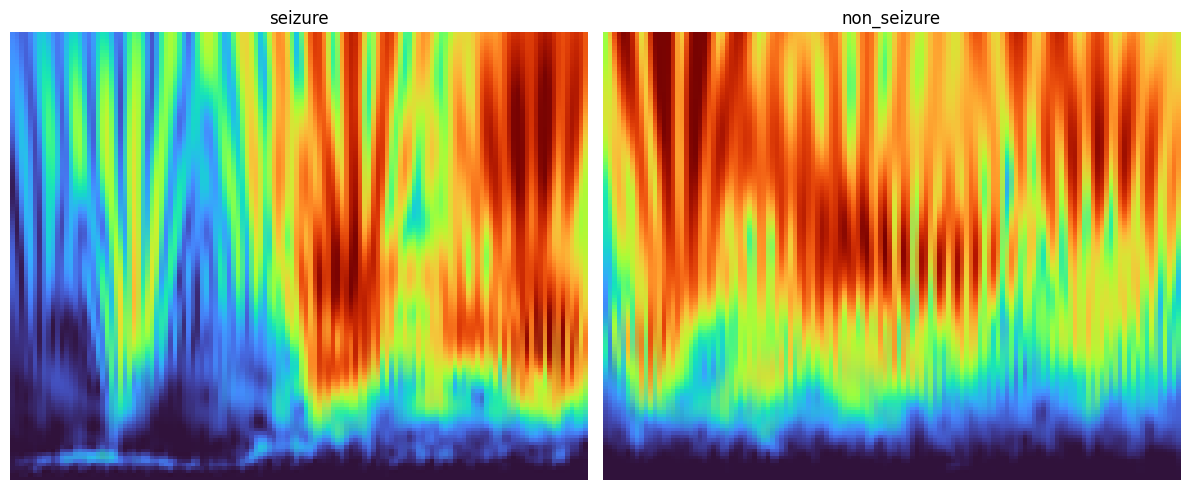

In [23]:
# =========================
# Cell 12 — Display example colored scalogram images
# =========================

import matplotlib.image as mpimg

sample_seizure = sorted(SEIZURE_DIR.glob("*.png"))[0]
sample_non_seizure = sorted(NON_SEIZURE_DIR.glob("*.png"))[0]

img_seizure = mpimg.imread(sample_seizure)
img_non_seizure = mpimg.imread(sample_non_seizure)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_seizure, aspect="auto", origin="lower")
axes[0].set_title("seizure")
axes[0].axis("off")

axes[1].imshow(img_non_seizure, aspect="auto", origin="lower")
axes[1].set_title("non_seizure")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_wavelet_images_color.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
# =========================
# Cell 13 — Stratified train/validation split for RGB images
# =========================

from sklearn.model_selection import train_test_split

class_names = ["non_seizure", "seizure"]

non_seizure_paths = sorted(NON_SEIZURE_DIR.glob("*.png"))
seizure_paths = sorted(SEIZURE_DIR.glob("*.png"))

image_paths = non_seizure_paths + seizure_paths
labels = [0] * len(non_seizure_paths) + [1] * len(seizure_paths)

image_paths = np.array([str(p) for p in image_paths])
labels = np.array(labels, dtype=np.int32)

print("Total images:", len(image_paths))
print("non_seizure images:", len(non_seizure_paths))
print("seizure images:", len(seizure_paths))
print("Labels distribution:", np.bincount(labels))

train_paths, val_paths, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
    shuffle=True
)

print("Train labels:", np.bincount(y_train))
print("Validation labels:", np.bincount(y_val))


def load_rgb_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, y_train))
train_ds = train_ds.map(load_rgb_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=len(train_paths), seed=SEED)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, y_val))
val_ds = val_ds.map(load_rgb_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Class names:", class_names)

Total images: 100
non_seizure images: 50
seizure images: 50
Labels distribution: [50 50]
Train labels: [40 40]
Validation labels: [10 10]
Class names: ['non_seizure', 'seizure']


In [34]:
# =========================
# Cell 14 — CNN model for RGB scalograms
# =========================

model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,761 (413.13 KB)

 Trainable params: 105,761 (413.13 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# =========================
# Cell 15 — Train CNN
# =========================

checkpoint_path = MODEL_DIR / "best_lab4_cnn_colored_scalogram.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5067 - loss: 0.6940
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/lab4_colored_scalograms/model/best_lab4_cnn_colored_scalogram.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.5095 - loss: 0.6938 - val_accuracy: 0.5000 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4728 - loss: 0.6942 
Epoch 2: val_accuracy did not improve from 0.50000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4742 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6927 - learning_rate: 1.0000e-04
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5996 - loss: 0.6918 
Epoch 3: val_accuracy did not improve from 0.50000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5928 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accurac

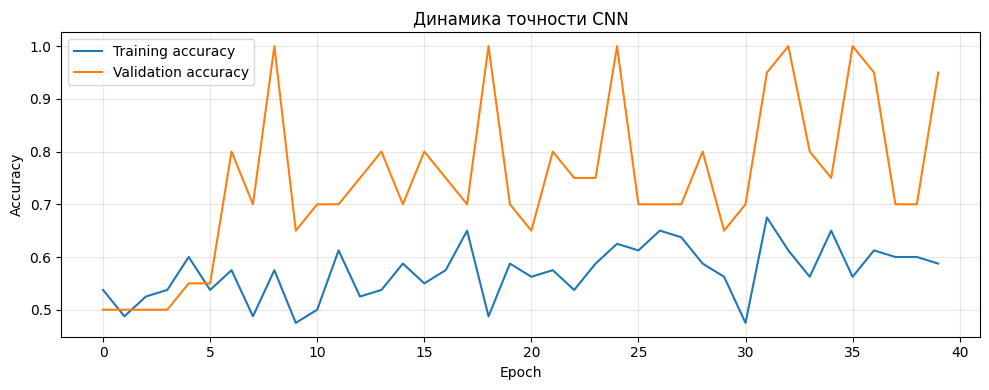

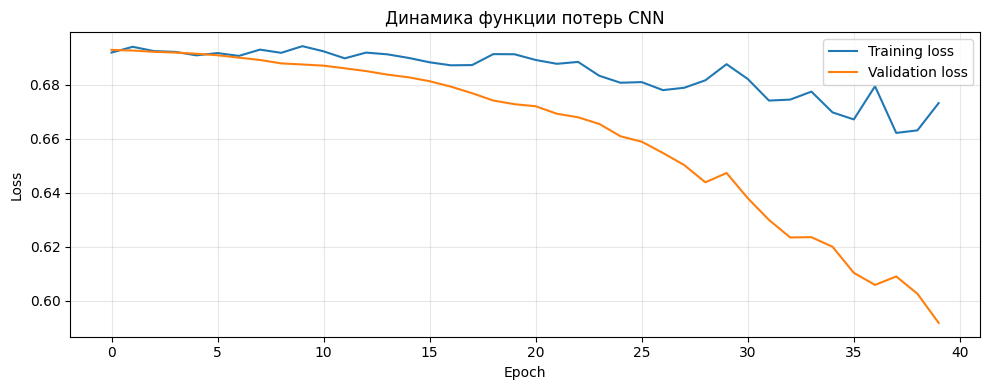

In [36]:
# =========================
# Cell 16 — Training curves
# =========================

history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

plt.figure(figsize=(10, 4))
plt.plot(history_df["accuracy"], label="Training accuracy")
plt.plot(history_df["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Динамика точности CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["loss"], label="Training loss")
plt.plot(history_df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Динамика функции потерь CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
# =========================
# Cell 17 — Evaluate model
# =========================

val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9281 - loss: 0.5976 
Validation loss: 0.5918
Validation accuracy: 0.9500


Unique y_true: (array([0, 1]), array([10, 10]))
Unique y_pred: (array([0, 1]), array([11,  9]))
Confusion matrix:
[[10  0]
 [ 1  9]]

Classification report:
              precision    recall  f1-score   support

 non_seizure       0.91      1.00      0.95        10
     seizure       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



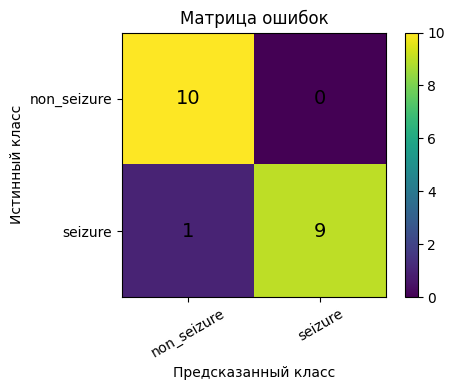

In [46]:
# =========================
# Cell 18 — Confusion matrix and classification report
# =========================

y_true = []
y_pred_prob = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred_prob.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Unique y_true:", np.unique(y_true, return_counts=True))
print("Unique y_pred:", np.unique(y_pred, return_counts=True))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=class_names,
    zero_division=0
)

print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(report)

with open(RESULTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(RESULTS_DIR / "confusion_matrix.csv")

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(range(len(class_names)), class_names, rotation=30)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.colorbar()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
# =========================
# Cell 19 — Save final model
# =========================

final_model_path = MODEL_DIR / "lab4_cnn_colored_scalogram_classifier.keras"
model.save(final_model_path)

print("Final model saved:")
print(final_model_path)

print("Best model saved:")
print(checkpoint_path)

Final model saved:
/kaggle/working/lab4_colored_scalograms/model/lab4_cnn_colored_scalogram_classifier.keras
Best model saved:
/kaggle/working/lab4_colored_scalograms/model/best_lab4_cnn_colored_scalogram.keras


In [48]:
# =========================
# Cell 20 — Test prediction on sample images
# =========================

def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE, color_mode="rgb")
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    prob = model.predict(img_array, verbose=0)[0][0]
    predicted_index = int(prob >= 0.5)
    predicted_class = class_names[predicted_index]
    
    return prob, predicted_class

test_seizure_image = sorted(SEIZURE_DIR.glob("*.png"))[0]
test_non_seizure_image = sorted(NON_SEIZURE_DIR.glob("*.png"))[0]

prob1, pred1 = predict_image(test_seizure_image)
prob2, pred2 = predict_image(test_non_seizure_image)

print("Test seizure image:", test_seizure_image.name)
print("Probability seizure:", float(prob1))
print("Predicted class:", pred1)

print("\nTest non-seizure image:", test_non_seizure_image.name)
print("Probability seizure:", float(prob2))
print("Predicted class:", pred2)

Test seizure image: seizure_000.png
Probability seizure: 0.40626174211502075
Predicted class: non_seizure

Test non-seizure image: non_seizure_000.png
Probability seizure: 0.4829515218734741
Predicted class: non_seizure


In [50]:
# =========================
# Cell 21 — Experiment summary
# =========================

experiment_summary = pd.DataFrame([
    {
        "dataset": "CHB-MIT Scalp EEG Database / chb08",
        "representation": "colored_wavelet_scalogram_rgb",
        "number_of_seizure_edf_files": len(seizure_records),
        "number_of_non_seizure_edf_files": len(non_seizure_files),
        "segment_duration_sec": SEGMENT_DURATION_SEC,
        "images_seizure": len(list(SEIZURE_DIR.glob("*.png"))),
        "images_non_seizure": len(list(NON_SEIZURE_DIR.glob("*.png"))),
        "total_images": len(list(DATASET_DIR.rglob("*.png"))),
        "sampling_rate_hz_original": SAMPLING_RATE,
        "target_sampling_rate_hz": TARGET_FS,
        "frequency_range_hz": f"{FREQ_MIN}-{FREQ_MAX}",
        "image_size": str(IMG_SIZE),
        "validation_loss": float(val_loss),
        "validation_accuracy": float(val_accuracy),
        "model_path": str(final_model_path)
    }
])

experiment_summary.to_csv(RESULTS_DIR / "experiment4_summary.csv", index=False)
display(experiment_summary)

,dataset,representation,number_of_seizure_edf_files,number_of_non_seizure_edf_files,segment_duration_sec,images_seizure,images_non_seizure,total_images,sampling_rate_hz_original,target_sampling_rate_hz,frequency_range_hz,image_size,validation_loss,validation_accuracy,model_path
0,CHB-MIT Scalp EEG Database / chb08,colored_wavelet_scalogram_rgb,5,15,8.0,50,50,100,256,128,1-60,"(128, 128)",0.591843,0.95,/kaggle/working/lab4_colored_scalograms/model/...


In [51]:
# =========================
# Cell 22 — Create ZIP archive
# =========================

import shutil

archive_path = shutil.make_archive(
    base_name=str(WORK_DIR / "lab4_colored_scalogram_outputs"),
    format="zip",
    root_dir=WORK_DIR
)

print("Archive created:")
print(archive_path)

print("\nMain outputs:")
print("- eeg_image_dataset/seizure/")
print("- eeg_image_dataset/non_seizure/")
print("- results/sample_wavelet_images_color.png")
print("- results/cnn_accuracy.png")
print("- results/cnn_loss.png")
print("- results/confusion_matrix.png")
print("- results/classification_report.txt")
print("- results/experiment4_summary.csv")
print("- model/lab4_cnn_colored_scalogram_classifier.keras")

Archive created:
/kaggle/working/lab4_colored_scalograms/lab4_colored_scalogram_outputs.zip

Main outputs:
- eeg_image_dataset/seizure/
- eeg_image_dataset/non_seizure/
- results/sample_wavelet_images_color.png
- results/cnn_accuracy.png
- results/cnn_loss.png
- results/confusion_matrix.png
- results/classification_report.txt
- results/experiment4_summary.csv
- model/lab4_cnn_colored_scalogram_classifier.keras


In [52]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

SAVE_DIR = Path("/kaggle/working/saved_project")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# مثال: حفظ الميزات
# features_df.to_csv(SAVE_DIR / "features.csv", index=False)

# مثال: حفظ مصفوفات NumPy
# np.save(SAVE_DIR / "X.npy", X)
# np.save(SAVE_DIR / "y.npy", y)

# مثال: حفظ النموذج
# joblib.dump(model, SAVE_DIR / "model.joblib")

print("Saved to:", SAVE_DIR)
!zip -r /kaggle/working/chb08_saved_project.zip /kaggle/working/chb08

Saved to: /kaggle/working/saved_project
updating: kaggle/working/chb08/ (stored 0%)
updating: kaggle/working/chb08/chb08_03.edf (deflated 41%)
updating: kaggle/working/chb08/chb08_19.edf (deflated 40%)
updating: kaggle/working/chb08/chb08_15.edf (deflated 38%)
updating: kaggle/working/chb08/chb08_05.edf.seizures (deflated 2%)
updating: kaggle/working/chb08/chb08_17.edf (deflated 38%)
updating: kaggle/working/chb08/chb08_12.edf (deflated 35%)
updating: kaggle/working/chb08/chb08_21.edf.seizures (deflated 4%)
updating: kaggle/working/chb08/chb08_18.edf (deflated 40%)
updating: kaggle/working/chb08/chb08_05.edf (deflated 36%)
updating: kaggle/working/chb08/chb08_22.edf (deflated 38%)
updating: kaggle/working/chb08/chb08_13.edf (deflated 34%)
updating: kaggle/working/chb08/chb08_11.edf (deflated 33%)
updating: kaggle/working/chb08/chb08_02.edf.seizures (deflated 2%)
updating: kaggle/working/chb08/chb08_13.edf.seizures (deflated 2%)
updating: kaggle/working/chb08/chb08-summary.txt (deflated

In [53]:
from pathlib import Path

print("Files saved in /kaggle/working:")
for p in Path("/kaggle/working").rglob("*"):
    if p.is_file():
        print(p)

Files saved in /kaggle/working:
/kaggle/working/chb08_saved_project.zip
/kaggle/working/chb08/chb08_03.edf
/kaggle/working/chb08/chb08_19.edf
/kaggle/working/chb08/chb08_15.edf
/kaggle/working/chb08/chb08_05.edf.seizures
/kaggle/working/chb08/chb08_17.edf
/kaggle/working/chb08/chb08_12.edf
/kaggle/working/chb08/chb08_21.edf.seizures
/kaggle/working/chb08/chb08_18.edf
/kaggle/working/chb08/chb08_05.edf
/kaggle/working/chb08/chb08_22.edf
/kaggle/working/chb08/chb08_13.edf
/kaggle/working/chb08/chb08_11.edf
/kaggle/working/chb08/chb08_02.edf.seizures
/kaggle/working/chb08/chb08_13.edf.seizures
/kaggle/working/chb08/chb08-summary.txt
/kaggle/working/chb08/chb08_20.edf
/kaggle/working/chb08/chb08_23.edf
/kaggle/working/chb08/chb08_11.edf.seizures
/kaggle/working/chb08/chb08_02.edf
/kaggle/working/chb08/chb08_14.edf
/kaggle/working/chb08/chb08_24.edf
/kaggle/working/chb08/chb08_29.edf
/kaggle/working/chb08/chb08_10.edf
/kaggle/working/chb08/chb08_21.edf
/kaggle/working/chb08/chb08_16.edf
/ka